# 📦 Import Required Libraries
This cell imports all necessary packages for image processing, clustering, and visualization.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random

# 🎯 K-Means Clustering Implementation
A vectorized implementation of k-means clustering with:
- Squared Euclidean distance (faster than standard)
- Empty cluster handling
- Early convergence detection

In [ ]:
def kmeans_clustering(data, k, max_iterations=100):
    # Random initialization (faster than sample)
    centroids = data[np.random.choice(len(data), k, replace=False)]

    for _ in range(max_iterations):
        # Vectorized distance calculation (biggest speedup)
        distances = np.sum((data[:, None] - centroids)**2, axis=2)  # Squared distances
        labels = np.argmin(distances, axis=1)

        # Update centroids (vectorized)
        new_centroids = np.array([data[labels == i].mean(axis=0) for i in range(k)])

        # Handle empty clusters by keeping previous centroid
        empty_clusters = np.isnan(new_centroids).any(axis=1)
        new_centroids[empty_clusters] = centroids[empty_clusters]

        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids

    return labels, centroids

# 🖼️ Ishihara Image Processing Pipeline
Processes color blindness test images by:
1. Performing k-means clustering on pixel colors
2. Visualizing all clusters
3. Allowing interactive number selection
4. Generating final extracted number mask

In [ ]:
def process_ishihara_image(image_path, k):
    # Load image and convert to an array with shape (height, width, 3)
    img = Image.open(image_path)
    img_array = np.array(img)

    # Reshape image data for clustering
    height, width, _ = img_array.shape
    pixels = img_array.reshape(-1, 3)

    # Apply K-means clustering
    labels, centroids = kmeans_clustering(pixels, k)

    # Reshape labels back to image dimensions
    segmented_image = labels.reshape(height, width)

    # First, display all individual clusters
    plt.figure(figsize=(15, 4))
    plt.subplot(1, k+1, 1)
    plt.imshow(img)
    plt.title('Original Image')
    plt.axis('off')

    for i in range(k):
        plt.subplot(1, k+1, i+2)
        binary_mask = (segmented_image == i).astype(np.uint8) * 255
        plt.imshow(binary_mask, cmap='gray')
        plt.title(f'Cluster {i}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    # Ask the user which cluster(s) contain the number
    print("Based on the clusters above, which cluster(s) contain the number?")
    print("Enter the cluster numbers separated by commas (e.g., '1,2'): ")
    user_input = input().strip()
    number_clusters = [int(c) for c in user_input.split(',')]

    # Create a merged mask from all selected clusters
    merged_mask = np.zeros_like(segmented_image)
    for cluster in number_clusters:
        merged_mask = np.logical_or(merged_mask, (segmented_image == cluster))

    merged_mask = merged_mask.astype(np.uint8) * 255

    # Display the final result
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(segmented_image, cmap='viridis')
    plt.title('Clustered Image')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(merged_mask, cmap='gray')
    if len(number_clusters) == 1:
        plt.title(f'Extracted Number (Cluster {number_clusters[0]})')
    else:
        plt.title(f'Extracted Number (Clusters {", ".join(map(str, number_clusters))})')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    return segmented_image, centroids, merged_mask

# 🚀 Run the Pipeline
Processes an Ishihara test image with different k for each image (high for demonstration)

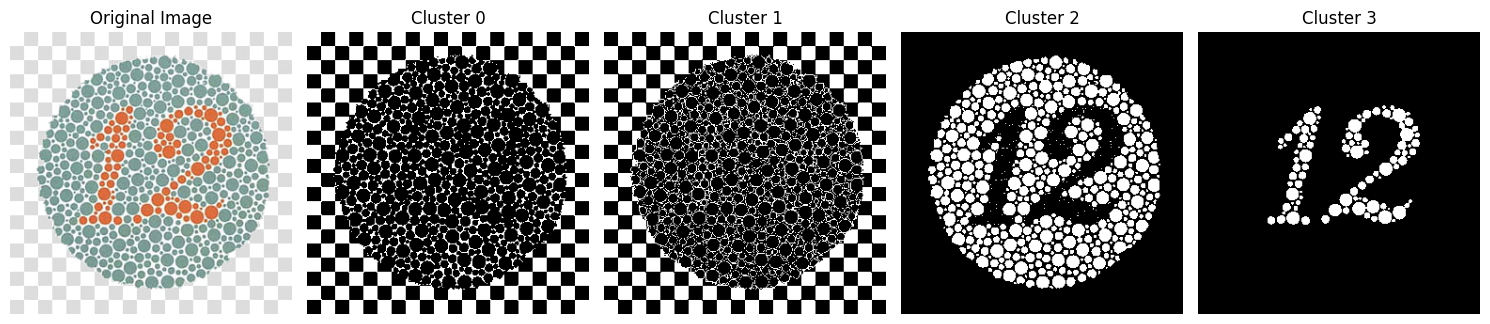

Based on the clusters above, which cluster(s) contain the number?
Enter the cluster numbers separated by commas (e.g., '1,2'): 
3


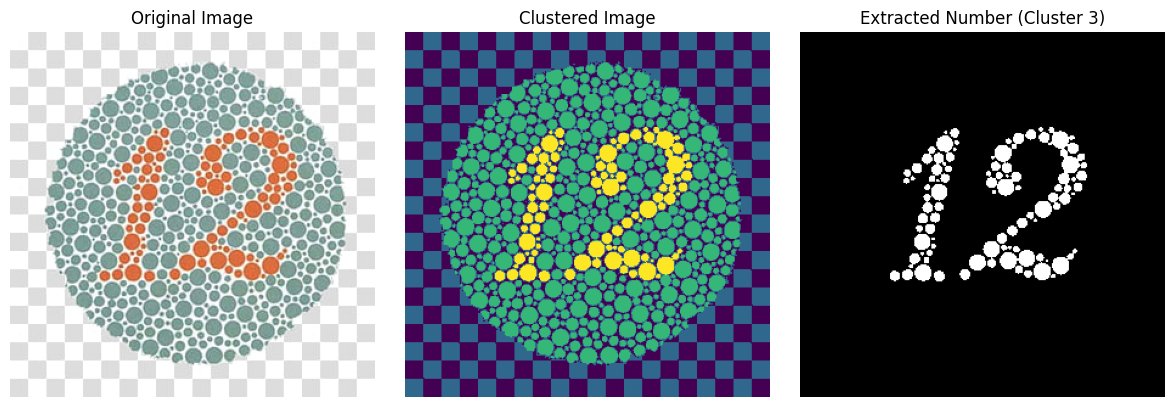

(array([[0, 0, 0, ..., 1, 1, 1],
        [0, 0, 0, ..., 1, 1, 1],
        [0, 0, 0, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0]]),
 [array([251.6692329 , 253.7160147 , 253.04827299]),
  array([217.02413602, 219.01951077, 217.02465718]),
  array([128.47272583, 155.27849407, 149.54707026]),
  array([205.14212329, 112.4815449 ,  72.293379  ])],
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8))

In [ ]:
# Example usage:
process_ishihara_image('12.jpg', 4)  # Adjust k as needed

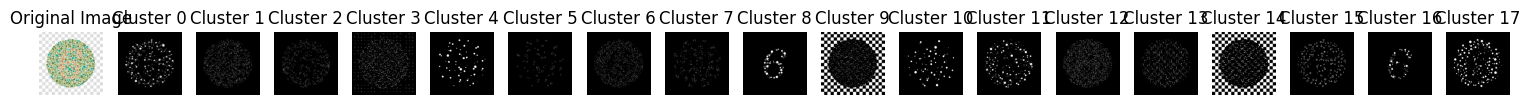

Based on the clusters above, which cluster(s) contain the number?
Enter the cluster numbers separated by commas (e.g., '1,2'): 
8,16


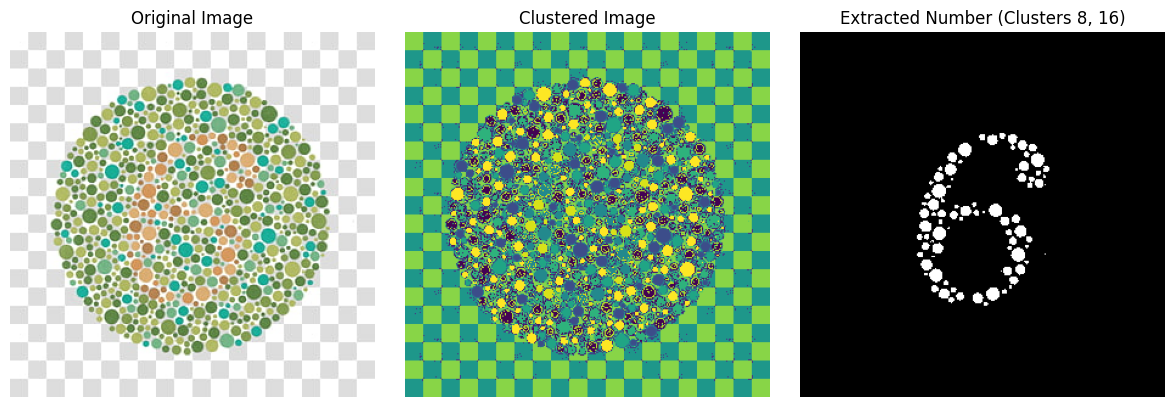

(array([[14, 14, 14, ...,  9,  9,  9],
        [14, 14, 14, ...,  9,  9,  9],
        [14, 14, 14, ...,  9,  9,  9],
        ...,
        [ 9,  9,  9, ..., 14, 14, 14],
        [ 9,  9,  9, ..., 14, 14, 14],
        [ 9,  9,  9, ..., 14, 14, 14]]),
 array([[100, 135,  73],
        [193, 196, 157],
        [137, 156, 113],
        [229, 234, 227],
        [ 26, 167, 146],
        [ 93, 179, 165],
        [163, 180, 142],
        [166, 208, 192],
        [213, 166, 112],
        [220, 221, 220],
        [115, 175, 131],
        [127, 151,  79],
        [211, 215, 188],
        [247, 250, 230],
        [254, 254, 254],
        [ 82, 118,  57],
        [178, 129,  79],
        [173, 181,  98]], dtype=uint8),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8))

In [ ]:
# Example usage:
process_ishihara_image('6.jpg', 18)

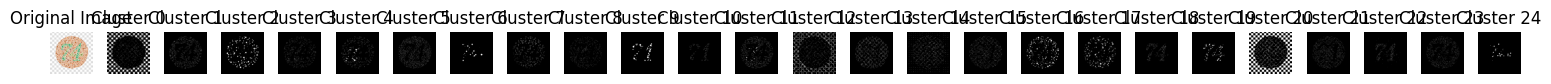

Based on the clusters above, which cluster(s) contain the number?
Enter the cluster numbers separated by commas (e.g., '1,2'): 
6,9,10,18,19,22,24


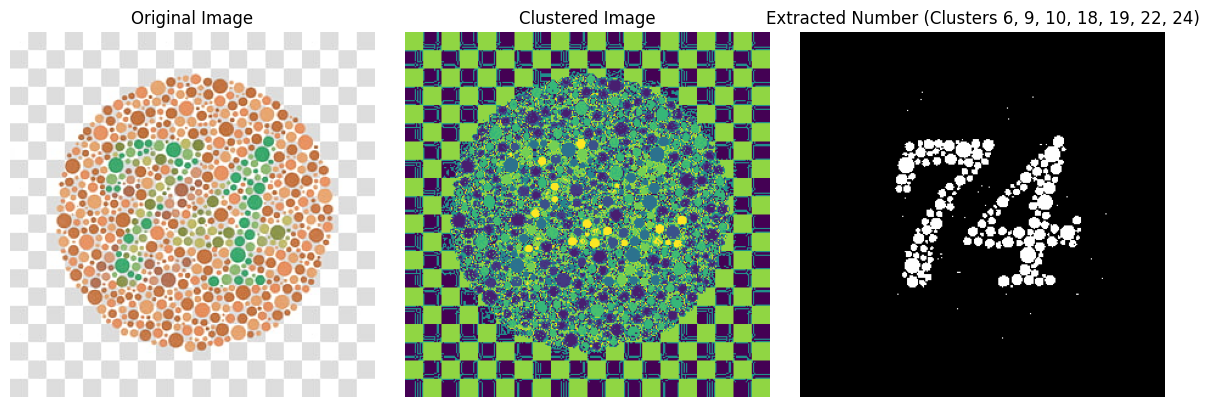

(array([[20, 20, 20, ...,  0,  0,  0],
        [20, 20, 20, ...,  0,  0,  0],
        [20, 20, 20, ...,  0,  0,  0],
        ...,
        [ 0,  0,  0, ..., 20, 20, 20],
        [ 0,  0,  0, ..., 20, 20, 20],
        [ 0,  0,  0, ..., 20, 20, 20]]),
 array([[220, 220, 219],
        [222, 172, 137],
        [199, 117,  65],
        [186, 134, 102],
        [173, 113,  78],
        [246, 222, 203],
        [132, 141,  72],
        [175, 101,  53],
        [195, 161, 137],
        [ 58, 162, 105],
        [102, 168, 131],
        [211, 153, 114],
        [223, 223, 222],
        [253, 246, 230],
        [231, 233, 232],
        [223, 207, 191],
        [232, 160, 108],
        [224, 140,  91],
        [159, 189, 151],
        [144, 174, 110],
        [254, 254, 254],
        [213, 186, 162],
        [187, 211, 186],
        [237, 198, 170],
        [187, 183, 107]], dtype=uint8),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,

In [ ]:
process_ishihara_image('74.jpg', 25)

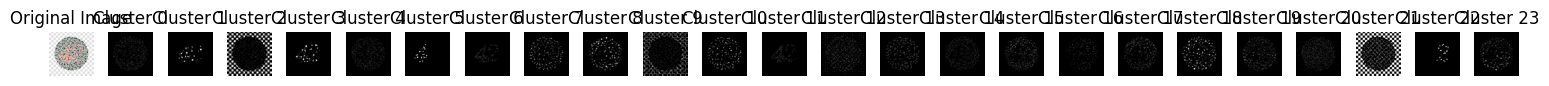

Based on the clusters above, which cluster(s) contain the number?
Enter the cluster numbers separated by commas (e.g., '1,2'): 
1,3,5,6,11,22


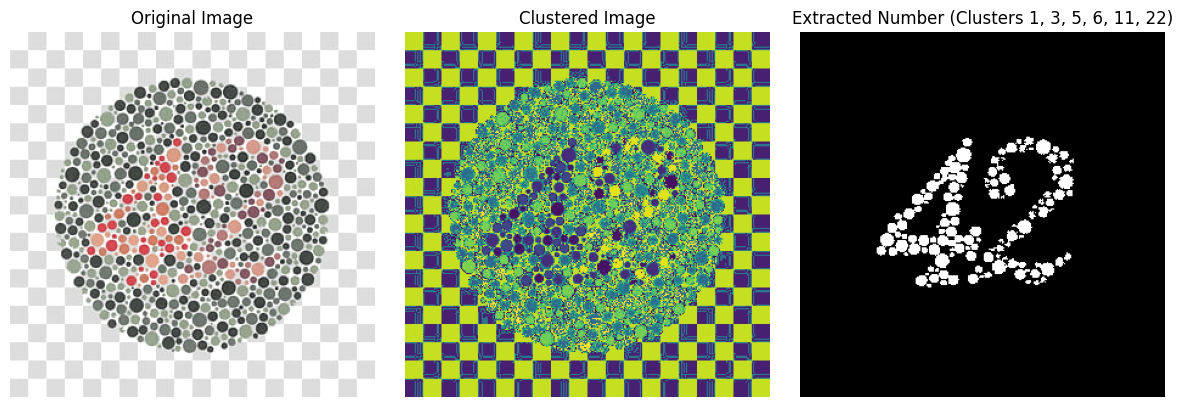

(array([[21, 21, 21, ...,  2,  2,  2],
        [21, 21, 21, ...,  2,  2,  2],
        [21, 21, 21, ...,  2,  2,  2],
        ...,
        [ 2,  2,  2, ..., 21, 21, 21],
        [ 2,  2,  2, ..., 21, 21, 21],
        [ 2,  2,  2, ..., 21, 21, 21]]),
 array([[207, 210, 205],
        [188, 119, 108],
        [220, 220, 220],
        [213, 153, 137],
        [194, 197, 191],
        [204,  67,  75],
        [218, 176, 168],
        [ 76,  80,  77],
        [106, 113, 107],
        [222, 223, 222],
        [ 63,  68,  64],
        [236, 205, 199],
        [231, 231, 228],
        [ 50,  54,  51],
        [178, 182, 175],
        [138, 145, 133],
        [ 35,  39,  36],
        [ 92,  97,  92],
        [150, 159, 143],
        [162, 168, 157],
        [242, 242, 238],
        [254, 254, 254],
        [128,  85,  95],
        [120, 126, 119]], dtype=uint8),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0

In [ ]:
process_ishihara_image('42.jpg', 24)